# Introduction à l'exploration des données

**Objectifs d'apprentissage :**  
- charger un jeu de données  
- explorer les données  
- découvrir les fonctions courantes d'exploration de variables
- et tester des premières visualisations

## Le pipeline de la Data Science

<!-- passage syntaxe html pour modifier la taille de l'image -->
<img src="https://mickaeltemporao.github.io/itds/images/pipeline.jpg" alt="pipeline" width="800"/>



## Acquisition de données
Avec quelques bases de Python, nous allons commencer à combiner des packages existants pour acquérir et explorer des données.


Avant de pouvoir commencer à examiner les données, nous devons les charger.

In [3]:
# Charger les bibliothèques requises
import pandas as pd

# Charger des données avec pandas depuis une URL
# data_url = UPDATE ÇA jean-MICHEL
# anes_data = pd.read_csv(data_url)


####
# FAUDRA VIRER ÇA APRÈS REVIEW AVEC MICKAEL
# ET UNE FOIS DÉCIDÉ SI ON FAIT UN PRÉRECODAGE
# DE VARIABLES QUANTI POUR ILLUSTRER SANS FAIRE PEUR
# oui tu sais que tu vas oublier
####

path = "/Users/leo/Desktop/data_anes/data_anes_2024.csv"
anes_data = pd.read_csv(path)


/var/folders/rq/xsj46x_s2rg87wdksm1_jl3c0000gn/T/ipykernel_25258/74390675.py:17: DtypeWarning: Columns (0: V200001, 1: V160001_orig, 2: V241156, 3: V241157, 4: V241158, 5: V241166, 6: V241167, 7: V241637c, 8: V243002, 9: V243050, 10: V243051, 11: V243052, 12: V243053, 13: V243055, 14: V243059, 15: V243056, 16: V243057, 17: V243058, 18: V243065, 19: V243066, 20: V243067) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_data = pd.read_csv(path)


In [ ]:
#TODO: check avec mickael
# POUR MICKAEL : ENJEU RECODAGE PUISQUE VRAIS LABELS
# IE SI ON VEUT DES TRUCS ILLUSTRATIFS QUANTI

# Option 1 : on fait un recodage en amont avant meme
# de mettre les données en ligne pour cette démo ?

# Option 2 : on laisse le code qui montre comment recoder une variable
# mais en disant qu'on leur montre ça la prochaine fois
# (risque de panique, mais c'est aussi comme ça qu'on dédramatise un peu)

In [28]:
# ex leur var d'âge est "quali" car label pour 80 ans et missing
anes_data["V241458x"].unique()

array(['50.0', '41.0', '44.0', '45.0', '80. Eighty years old or older',
       '75.0', '49.0', '59.0', '34.0', '42.0', '70.0', '58.0', '66.0',
       '35.0', '28.0', '77.0', '76.0', '54.0', '64.0', '32.0', '78.0',
       '52.0', '57.0', '-2. Missing, exact birth date not given', '46.0',
       '74.0', '69.0', '43.0', '37.0', '65.0', '25.0', '47.0', '48.0',
       '40.0', '38.0', '79.0', '62.0', '61.0', '56.0', '27.0', '31.0',
       '68.0', '33.0', '53.0', '71.0', '73.0', '26.0', '67.0', '51.0',
       '60.0', '39.0', '55.0', '63.0', '72.0', '29.0', '36.0', '24.0',
       '30.0', '23.0', '22.0', '18.0', '21.0', '20.0', '19.0'],
      dtype=object)

In [ ]:
# recodage possible :
anes_data["V241458x"] = anes_data["V241458x"].replace({
    "80. Eighty years old or older": 80,
    "-2. Missing, exact birth date not given": None
}).astype(float)

In [ ]:
# idem aviser pour l'idéologie si tu voulais leur faire des stat/graph
# cf fin de document
anes_data["V241177"].unique()

array(['6. Conservative', '4. Moderate; middle of the road', '2. Liberal',
       "99. Haven't thought much about this", '5. Slightly conservative',
       '3. Slightly liberal', '1. Extremely liberal',
       '7. Extremely conservative', '-9. Refused', '-4. Error'],
      dtype=object)

### Hack Time

In [4]:
# Quel est le type de anes_data ?


### DataFrames

Les DataFrames sont des listes (ou des séries lorsqu'on utilise pandas) qui sont assemblées dans un tableau.

![](https://storage.googleapis.com/lds-media/images/series-and-dataframe.width-1200.png)

In [5]:
# Un exemple rapide
participation = [66.8, 55.7, 54.9, 58.2, 56.7, 51.2, 49.0]
annee = [2020, 2016, 2012, 2008, 2004, 2000, 1996]
parti = ["Dem", "Rep", "Dem", "Dem", "Rep", "Rep", "Dem"]

# Nous créons un DataFrame à partir de zéro
my_data = pd.DataFrame(
    {
        "participation": participation,
        "année": annee,
        "parti": parti,
    }
)

In [6]:
# Quel est le type de `my_data`


In [7]:
# Regardez le nouveau jeu de données que vous venez de créer
my_data


,participation,année,parti
0,66.8,2020,Dem
1,55.7,2016,Rep
2,54.9,2012,Dem
3,58.2,2008,Dem
4,56.7,2004,Rep
5,51.2,2000,Rep
6,49.0,1996,Dem


In [8]:
# Nous pouvons également en apprendre plus sur notre objet en utilisant la méthode `.info()`.
my_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   participation  7 non-null      float64
 1   année          7 non-null      int64  
 2   parti          7 non-null      object 
dtypes: float64(1), int64(1), object(1)
memory usage: 300.0+ bytes


In [9]:
# Lorsque votre jeu de données est trop long, vous pourriez vouloir afficher les premières
# observations (lignes) en utilisant la méthode `.head()`.
my_data.head()


,participation,année,parti
0,66.8,2020,Dem
1,55.7,2016,Rep
2,54.9,2012,Dem
3,58.2,2008,Dem
4,56.7,2004,Rep


### Hack Time

In [10]:
# Regardez le début des données anes_data


In [11]:
# Regardez les info des données anes_data


## Exploration de données - Variables

Maintenant que vous avez vos données, l'étape suivante est de vous familiariser avec elles. 

La plupart du temps, vous vous intéressez à certains concepts spécifiques. 
- Vous avez besoin d'un moyen de sélectionner uniquement les variables liées à vos concepts.


### Sélectionner des variables (colonnes)

Supposons que vous souhaitiez explorer les intentions de participation électorale des citoyens américains (`V241042`).

- Nous pouvons utiliser des crochets sur un objet DataFrame pour sélectionner une seule colonne !
- Nous pouvons également utiliser une liste de chaînes contenant les noms de colonnes pour sélectionner plusieurs colonnes !

![](https://pandas.pydata.org/docs/_images/03_subset_columns.svg)


In [12]:
# L'attribut `columns` permet d'obtenir les noms des colonnes d'un DataFrame
anes_data.columns

Index(['Unnamed: 0', 'version', 'V240001', 'V200001', 'V160001_orig',
       'V240002a', 'V240002b', 'V240002c', 'V240003', 'V240101a',
       ...
       'V245009', 'V245010', 'V245011', 'V245012', 'V245013', 'V245014',
       'V245015', 'V245016', 'V245017', 'V245018'],
      dtype='object', length=1723)

In [ ]:
# Sélectionner la variable d'intention de vote
anes_data["V241042"]

0                 1. Yes
1                 1. Yes
2                 1. Yes
3                 1. Yes
4                 1. Yes
              ...       
5516              1. Yes
5517              1. Yes
5518    -1. Inapplicable
5519              1. Yes
5520              1. Yes
Name: V241042, Length: 5521, dtype: object

In [30]:
# Nous pouvons également la sauvegarder dans un nouvel objet et vérifier son type
vote_int = anes_data["V241042"]
type(vote_int)


pandas.core.series.Series

Supposons que vous souhaitiez également savoir pour qui les gens ont l'intention de voter en fonction de leur âge et de leur idéologie ? Dans ce cas, vous pourriez avoir besoin de sélectionner plusieurs variables.

In [4]:
#TODO: check avec mickael si les var sont ok pour lui

# Sélectionner plusieurs colonnes
my_vars = [
    "V241042",  # a l'intention de voter ?
    "V241043",  # pour qui a l'intention de voter ?
    "V241458x",  # age
    "V241177",  # autoplacement sur une échelle libéral-conservateur
]

anes_data[my_vars]

,V241042,V241043,V241458x,V241177
0,1. Yes,2. Donald Trump,50.0,6. Conservative
1,1. Yes,"3. Robert F. Kennedy, Jr.",41.0,4. Moderate; middle of the road
2,1. Yes,1. Kamala Harris,44.0,2. Liberal
3,1. Yes,2. Donald Trump,45.0,99. Haven't thought much about this
4,1. Yes,2. Donald Trump,80. Eighty years old or older,4. Moderate; middle of the road
...,...,...,...,...
5516,1. Yes,-8. Don't know,"-2. Missing, exact birth date not given",4. Moderate; middle of the road
5517,1. Yes,1. Kamala Harris,69.0,3. Slightly liberal
5518,-1. Inapplicable,-1. Inapplicable,"-2. Missing, exact birth date not given",99. Haven't thought much about this
5519,1. Yes,1. Kamala Harris,28.0,1. Extremely liberal


In [5]:
# Sauvegarder ce sous-ensemble plus petit de variables dans my_df
my_df = anes_data[my_vars]
print(type(my_df))
print(my_df.columns)
my_df.head()

<class 'pandas.DataFrame'>
Index(['V241042', 'V241043', 'V241458x', 'V241177'], dtype='str')


,V241042,V241043,V241458x,V241177
0,1. Yes,2. Donald Trump,50.0,6. Conservative
1,1. Yes,"3. Robert F. Kennedy, Jr.",41.0,4. Moderate; middle of the road
2,1. Yes,1. Kamala Harris,44.0,2. Liberal
3,1. Yes,2. Donald Trump,45.0,99. Haven't thought much about this
4,1. Yes,2. Donald Trump,80. Eighty years old or older,4. Moderate; middle of the road


Pour éviter d'avoir toujours à vérifier le codebook, nettoyons un peu nos données en rendant les noms des colonnes plus explicites.

In [6]:
# Renommer les colonnes
my_df.columns = ["vote", "vote_int", "age", "idéologie"]
my_df.head()

,vote,vote_int,age,idéologie
0,1. Yes,2. Donald Trump,50.0,6. Conservative
1,1. Yes,"3. Robert F. Kennedy, Jr.",41.0,4. Moderate; middle of the road
2,1. Yes,1. Kamala Harris,44.0,2. Liberal
3,1. Yes,2. Donald Trump,45.0,99. Haven't thought much about this
4,1. Yes,2. Donald Trump,80. Eighty years old or older,4. Moderate; middle of the road


### Méthodes utiles
Les Series et les DataFrames fournissent des méthodes très utiles pour explorer facilement les données. Voici quelques-unes des plus courantes :

- `mean()` : moyenne
- `median()` : médiane
- `std()` : écart-type
- `min()` : minimum
- `max()` : maximum
- `mode()` : mode (valeur la plus fréquente)
- `count()` : nombre d'observations
- `describe()` : statistiques descriptives
- `value_counts()` : fréquence des valeurs (tri à plat)

Rappel de celles vues plus haut :
- `info()` : informations sur le DataFrame (types, valeurs manquantes)
- `head()` : premières lignes
- `tail()` : dernières lignes




In [7]:
# Combien de personnes ont l'intention d'aller voter ?
my_df["vote"].value_counts()


vote
1. Yes              4619
-1. Inapplicable     449
2. No                436
-8. Don't know        14
-9. Refused            3
Name: count, dtype: int64

In [8]:
# Quel pourcentage des gens pensent aller voter ?
my_df["vote"].value_counts(normalize=True)


vote
1. Yes              0.836624
-1. Inapplicable    0.081326
2. No               0.078971
-8. Don't know      0.002536
-9. Refused         0.000543
Name: proportion, dtype: float64

In [9]:
# Un peu plus propre
my_results = my_df["vote"].value_counts(normalize=True) * 100
my_results.round(1)


vote
1. Yes              83.7
-1. Inapplicable     8.1
2. No                7.9
-8. Don't know       0.3
-9. Refused          0.1
Name: proportion, dtype: float64

### Hack Time

In [10]:
#TODO: check avec mickael si on précode l'age en quanti
# ou si on change d'exemple

# Quel est l'age moyen des répondants ?


In [11]:
#TODO: marche dans les deux cas mais voir si recode pour simili quanti
# Quelle est l'idéologie des répondants dans le jeu de données anes 2024 ?

In [12]:
# Quelle est la proportion de personnes ayant
# l'intention de voter pour kamala harris ?


## NOTRE PREMIER GRAPHIQUE (MOCHE) AVEC PANDAS

<Axes: xlabel='vote_int'>

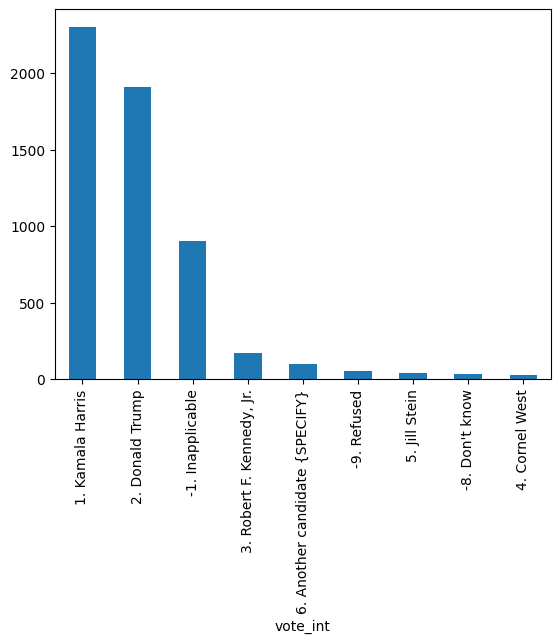

In [14]:
my_df["vote_int"].value_counts().plot(kind="bar")

## Visualisation de données

Une fois que vous avez trouvé les informations dont vous avez besoin, il est généralement judicieux de représenter graphiquement vos résultats. En effet, une visualisation vous aidera parfois à mieux comprendre les problèmes liés à vos données !

La plupart du temps, vous utiliserez des graphiques en barres et des histogrammes pour visualiser une seule variable, selon son type.

### Types de données

Nous avons vu qu'il existe différents types de données en Python (chaînes de caractères, entiers, décimaux, booléens, ...). Lorsqu'on fait de la recherche, nous pouvons regrouper les données en grandes familles : les données numériques/quantitatives et catégorielles/qualitatives

Les **données numériques** ("quantitatives") : caractéristiques quantifiables, des nombres qui mesurent des quantités. On peut distinguer 2 sous catégories :
- Numériques **continues**, qui peuvent prendre un nombre infini de valeurs.
  - La taille d'un étudiant (par ex. 182.5 cm)
  - Pour ces variables, vous utiliserez généralement des **histogrammes**.
- Numériques **discrètes**, qui ne peuvent prendre qu'un nombre fini de valeurs.
  - Le nombre d'étudiants dans une classe (par ex. 22)
  - Pour ces variables, vous utiliserez des **histogrammes** ou des **diagrammes en barres**.

Les données **catégorielles** ("qualitatives") : caractéristiques qui ne sont pas mesurables numériquement. On peut distinguer 2 sous catégories :
- Catégorielles **nominales** : les valeurs sont des modalités, des catégories sans hiérarchie 
  - Le genre d'un étudiant, sa couleur de cheveux, sa discipline (par ex. Sociologie)
- Catégorielles **ordinales** : on peut ordonner les catégories.
   - (par ex. Jamais/parfois/souvent/toujours)
- Pour ces variables, vous utiliserez des **diagrammes en barres**.


>C'est plus compliqué que ça :
>- zones grises entre les types de variables.
>- plein de sortes de graphiques possibles, des "règles" et plein d'exceptions, etc.  
>
>**TIP : ** Pour vous aider à choisir le type adapté de visualisation, regardez par là :  [**Data to Viz**]( https://www.data-to-viz.com/)

**N'oubliez pas de synthétiser/regrouper/résumer vos données avant de les tracer !**

- Sinon votre ordinateur ne sera pas content...



### Visualisations avec Pandas

Vous pouvez utiliser pandas pour tracer vos résultats en utilisant la méthode `.plot()` sur un objet DataFrame ou Series.

Pour plus d'informations, cliquez [**ici**](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).


In [ ]:
# Traçons la distribution de la variable age.
my_df["age"].plot(kind="hist")


In [ ]:
# Approfondir
my_df["age"].plot(kind="hist", bins=40)


In [ ]:
# Regardons l'intention de participation

# on avait déjà fait un objet results plus haut :
# cf : my_results = my_df["vote"].value_counts(normalize=True) * 100

my_results.plot(kind="bar")


### Hack Time

In [ ]:
# Est-ce que les citoyens américains sont polarisés ?

In [ ]:
# Qui aurait gagné le vote populaire selon l'ANES 2024 ?


### Aller plus loin

Il existe de nombreuses options pour jouer avec et améliorer une figure. 
Lorsque vous cherchez de l'aide pour changer quelque chose sur une figure, si vous avez la bonne terminologie, il est assez facile de trouver de l'aide !

#### Anatomie d'une figure
![Anatomie d'une figure](https://matplotlib.org/3.1.1/_images/anatomy.png)

Essayons d'améliorer un peu notre graphique des types de pokemons

# A finir de traduire et adapter aux données :

In [ ]:
# Filtering Observations (for next time)
mask = my_df["vote_int"].between(1, 4)

# Summarizing the data
tmp_data = (
    my_df.loc[mask, "vote_int"]
    .replace({1: "Biden", 2: "Trump", 3: "Jorgensen", 4: "Hawkins"})
    .value_counts(normalize=True)
)

# Making a plot/graphic/figure
tmp_data.plot(
    kind="bar",
    title="Voting Intentions",
    ylabel="Percentage",
    rot=0,
);


In [ ]:
# Is there a relationship between Age and Ideology?
my_vars = ["age", "ideology"]
mask = my_df["ideology"].between(1, 7)
my_df.loc[mask, my_vars].boxplot(by="ideology")
